In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import features as ft
import re
import pyarrow

In [2]:
features_df = pd.read_parquet(r"..\data\features.parquet", engine="pyarrow")

# Chunk de una hora

In [3]:
hours = 1
# clustering_data = features_raw_df.copy()
# Apply filters to the time series of the features
features_df = features_df[(features_df['energy']>=0)&(features_df['kurtosis']<2500)&(features_df['frequency_index']>=-3)&(features_df['entropy']>=0)&(features_df['entropy']<15000)]
# Calculate moving average for all features
features_df['energy_movil_mean'] = np.log10(features_df['energy'].rolling(window=11*hours, center=False).mean())
features_df['kurtosis_mobile_mean'] = np.log10(features_df['kurtosis'].rolling(window=11*hours, center=False).mean())
features_df['frequency_index_movil_mean'] = features_df['frequency_index'].rolling(window=11*hours, center=False).mean()
features_df['entropy_movil_mean'] = features_df['entropy'].rolling(window=11*hours, center=False).mean()

features_df['energy'] = np.log10(features_df['energy'])
features_df['kurtosis'] = np.log10(features_df['kurtosis'])

In [4]:
features_df_run = features_df[features_df['timestamp']<"2022-02-01"]

features_df_run

,timestamp,energy,kurtosis,frecuency_index,entropy,frequency_index,energy_movil_mean,kurtosis_mobile_mean,frequency_index_movil_mean,entropy_movil_mean
0,2022-01-01 00:05:00,7.074324,0.633977,None,6743.988806,-0.005959,NaN,NaN,NaN,NaN
1,2022-01-01 00:10:00,7.020175,0.632777,None,7043.316623,-0.109812,NaN,NaN,NaN,NaN
2,2022-01-01 00:15:00,7.011306,0.751629,None,7175.473832,0.032564,NaN,NaN,NaN,NaN
3,2022-01-01 00:20:00,7.010472,0.750180,None,7186.277967,0.065660,NaN,NaN,NaN,NaN
4,2022-01-01 00:25:00,6.986411,0.732571,None,7290.097859,-0.179743,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
8892,2022-01-31 23:35:00,8.830721,2.334161,None,1668.982751,0.629002,8.471704,1.573340,0.347591,2194.681709
8893,2022-01-31 23:40:00,8.817154,2.361190,None,1705.372009,0.451853,8.512201,1.760099,0.385613,2178.716875
8894,2022-01-31 23:45:00,8.051987,0.780485,None,2927.230991,0.083474,8.474237,1.714692,0.360933,2273.282381
8895,2022-01-31 23:50:00,7.990021,0.815191,None,3100.668472,0.158434,8.432990,1.659252,0.330689,2379.334500


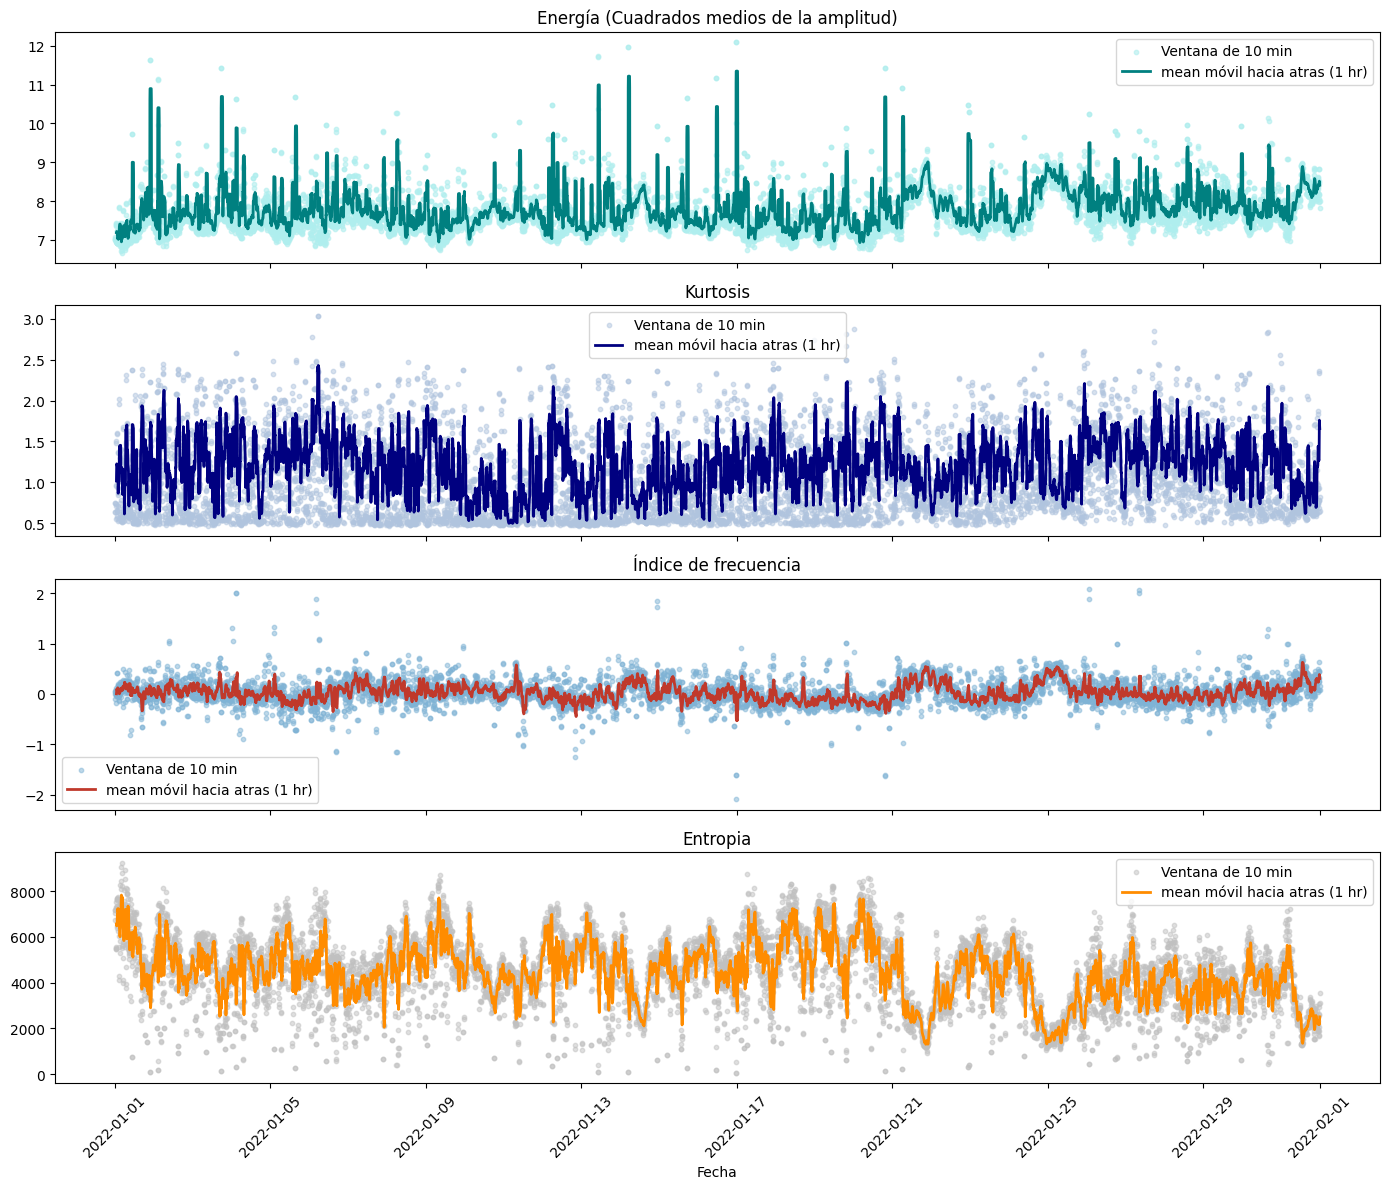

In [8]:
# Generate the plot
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 12), sharex=True)
axes[0].scatter(features_df_run['timestamp'], features_df_run['energy'], color='paleturquoise', s=10, alpha=0.6, label="Ventana de 10 min")
axes[0].plot(features_df_run['timestamp'], features_df_run['energy_movil_mean'], color='teal', linewidth=2, label= f'mean móvil hacia atras ({hours} hr)')
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(loc='best')

axes[1].scatter(features_df_run['timestamp'], features_df_run['kurtosis'], color='lightsteelblue', s=10, alpha=0.5, label = "Ventana de 10 min")
axes[1].plot(features_df_run['timestamp'], features_df_run['kurtosis_mobile_mean'], color='navy', alpha = 1,linewidth=2, label= f'mean móvil hacia atras ({hours} hr)')
axes[1].set_title('Kurtosis')
axes[1].legend(loc='best')

axes[2].scatter(features_df_run['timestamp'], features_df_run['frequency_index'], color='#7FB3D5', s=10, alpha=0.5, label = "Ventana de 10 min")
axes[2].plot(features_df_run['timestamp'], features_df_run['frequency_index_movil_mean'], color='#C0392B', alpha = 1,linewidth=2, label= f'mean móvil hacia atras ({hours} hr)')
axes[2].set_title('Índice de frecuencia')
axes[2].legend(loc='best')

axes[3].scatter(features_df_run['timestamp'], features_df_run['entropy'], color='silver', s=10, alpha=0.5, label = "Ventana de 10 min")
axes[3].plot(features_df_run['timestamp'], features_df_run['entropy_movil_mean'], color='darkorange', alpha = 1,linewidth=2, label= f'mean móvil hacia atras ({hours} hr)')
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(loc='best')

plt.xticks(rotation=45)
plt.tight_layout()

# Clustering model

In [5]:
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline

In [6]:
clustering_data_run = features_df_run[
    [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]
]

# Drop rows with missing values
clustering_data_run = clustering_data_run.dropna()

# Select columns to scale
cols_to_scale =  [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]

# Crea y entrena un escalador (Robust scaler)
scaler = MinMaxScaler()
#scaler.fit(clustering_data)

scaled_data = scaler.fit_transform(clustering_data_run[cols_to_scale])

# 4. Convert the NumPy array back to a DataFrame and maintain index/columns
df_scaled = pd.DataFrame(scaled_data, columns=cols_to_scale, index=clustering_data_run.index)


X_run = df_scaled[
    [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]
]



In [7]:
# Trata con differentes valores para k
inertia = []
silh = []
k_s = np.arange(2, 16)
for k in k_s:
  km_model = KMeans(n_clusters=k).fit(X_run)
  inertia.append(km_model.inertia_)
  silh.append(silhouette_score(X_run, km_model.labels_))

KeyboardInterrupt: 

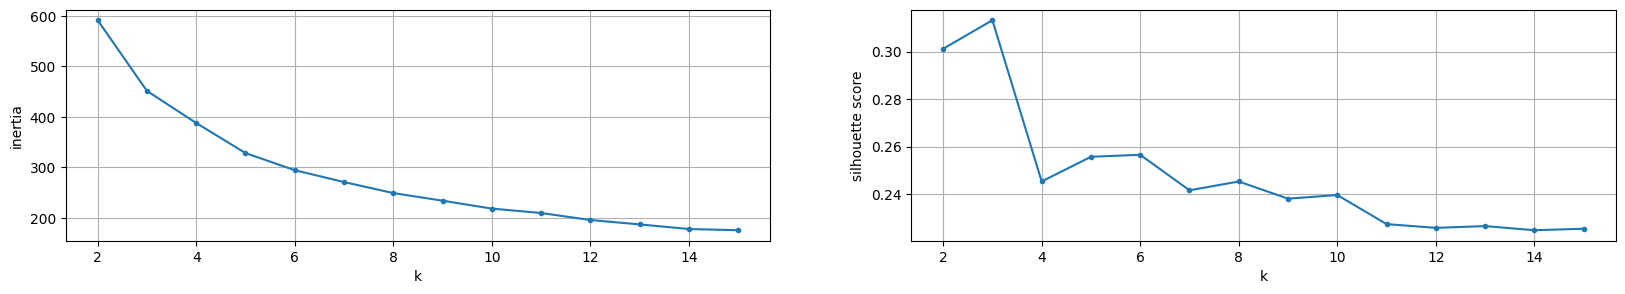

In [9]:
# Plot results
plt.figure(figsize=(20, 3))
plt.subplot(1, 2, 1)
plt.plot(k_s, inertia, '.-')
plt.grid()
plt.xlabel('k')
plt.ylabel('inertia')
plt.subplot(1, 2, 2)
plt.plot(k_s, silh, '.-')
plt.grid()
plt.xlabel('k')
plt.ylabel('silhouette score')
plt.show()

In [8]:
# Repite k-means con el mejor número k
km_model_1 = KMeans(n_clusters=3).fit(X_run)
distances = km_model_1.transform(X_run)

#clustering_data = X
clustering_data_run['timestamp'] = features_df['timestamp']

clustering_data_run['labels'] = km_model_1.labels_


clustering_data_run['distance_to_centroid'] = [distances[i, label] for i, label in enumerate(km_model_1.labels_)]

#clustering_data_run['log_distance_to_centroid'] = np.log(clustering_data_run['distance_to_centroid'])


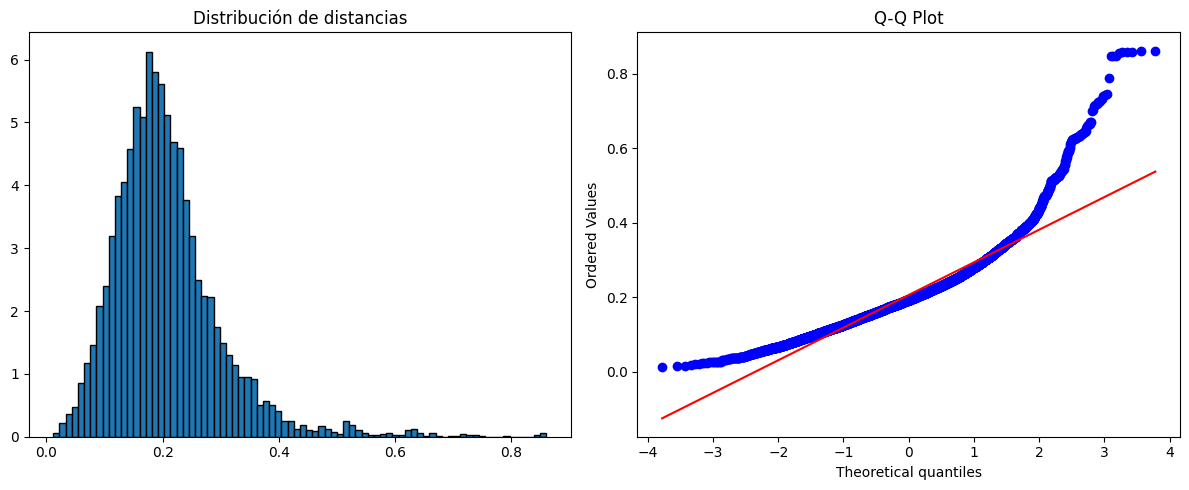

In [9]:
import matplotlib.pyplot as plt
import scipy.stats as stats

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma
axes[0].hist(clustering_data_run['distance_to_centroid'], bins=80, density=True, edgecolor='black')
axes[0].set_title('Distribución de distancias')

# Q-Q plot
stats.probplot(clustering_data_run['distance_to_centroid'], plot=axes[1])
axes[1].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

In [12]:
"""
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma
axes[0].hist(clustering_data['log_distance_to_centroid'], bins=80, density=True, edgecolor='black')
axes[0].set_title('Distribución de distancias')

# Q-Q plot
stats.probplot(clustering_data['log_distance_to_centroid'], plot=axes[1])
axes[1].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()
"""

"\nfig, axes = plt.subplots(1, 2, figsize=(12, 5))\n\n# Histograma\naxes[0].hist(clustering_data['log_distance_to_centroid'], bins=80, density=True, edgecolor='black')\naxes[0].set_title('Distribución de distancias')\n\n# Q-Q plot\nstats.probplot(clustering_data['log_distance_to_centroid'], plot=axes[1])\naxes[1].set_title('Q-Q Plot')\n\nplt.tight_layout()\nplt.show()\n"

In [13]:
# Rango de valores típicos (suponiendo normalidad) para el logaritmo de las distancias
#np.mean(clustering_data['log_distance_to_centroid']) - 3*np.std(clustering_data['log_distance_to_centroid']) , np.mean(clustering_data['log_distance_to_centroid']) + 3*np.std(clustering_data['log_distance_to_centroid'])

In [14]:
# Rango de valores observados para el logaritmo de las distancias
#np.min(clustering_data['log_distance_to_centroid']),np.max(clustering_data['log_distance_to_centroid'])

In [15]:
# Rango de valores observados
np.min(clustering_data_run['distance_to_centroid']),np.max(clustering_data_run['distance_to_centroid'])

(0.011191852826878144, 0.8600564848801262)

In [10]:
# Cálculo de cuartiles y cota superior de valores
Q1 = clustering_data_run['distance_to_centroid'].quantile(0.25)
Q3 = clustering_data_run['distance_to_centroid'].quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 3*IQR
#1.5
upper

0.5365827836744267

In [11]:
# Clasificamos los valores observados como típicos y atípicos
clustering_data_run['outliers'] = clustering_data_run['distance_to_centroid'] > upper
#clustering_data['outliers']

In [12]:
# Sort clustering data by timestamp
clustering_data_run = clustering_data_run.sort_values(by='timestamp')

In [13]:
# Distribución de número de observaciones por grupo
clustering_data_run[['labels','timestamp']].groupby('labels').count()

,timestamp
labels,
0,3246
1,1406
2,4231


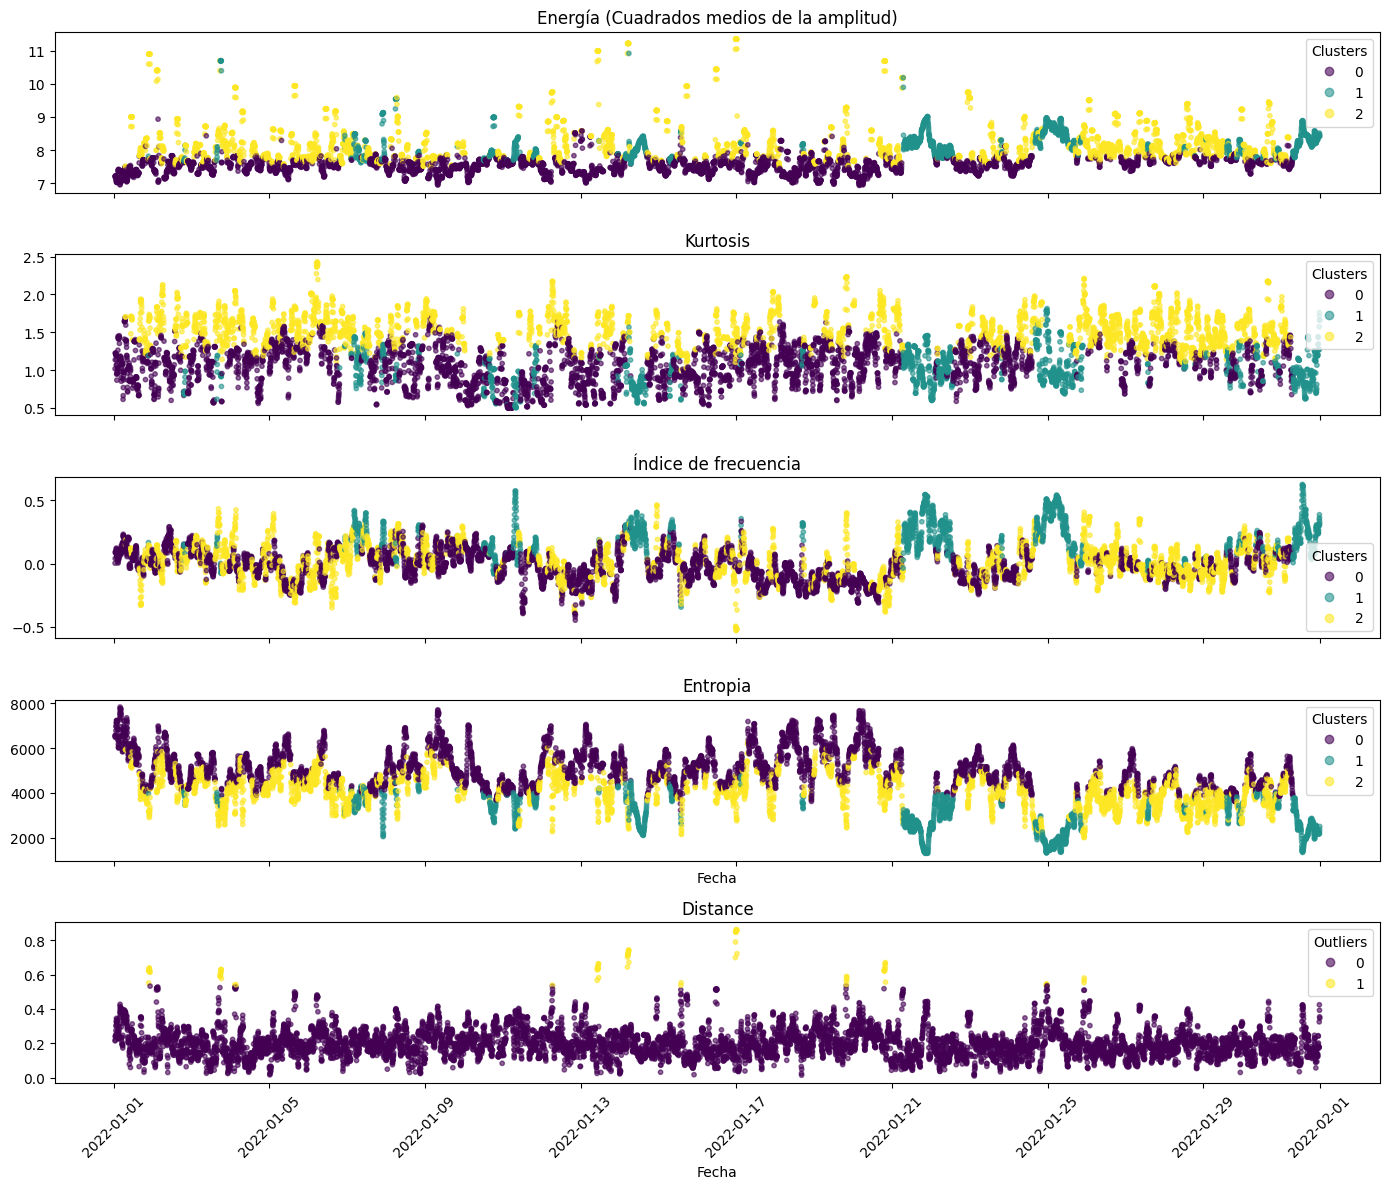

In [17]:
# Generate the plot
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 12), sharex=True)
scatter = axes[0].scatter(clustering_data_run['timestamp'], clustering_data_run['energy_movil_mean'], c=clustering_data_run['labels'], cmap='viridis', s=10, alpha=0.6)
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[1].scatter(clustering_data_run['timestamp'], clustering_data_run['kurtosis_mobile_mean'], c=clustering_data_run['labels'], cmap='viridis', s=10, alpha=0.6)
axes[1].set_title('Kurtosis')
axes[1].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[2].scatter(clustering_data_run['timestamp'], clustering_data_run['frequency_index_movil_mean'], c=clustering_data_run['labels'], cmap='viridis', s=10, alpha=0.6)
axes[2].set_title('Índice de frecuencia')
axes[2].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[3].scatter(clustering_data_run['timestamp'], clustering_data_run['entropy_movil_mean'], c=clustering_data_run['labels'], cmap='viridis', s=10, alpha=0.6)
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(*scatter.legend_elements(), title="Clusters")


scatter = axes[4].scatter(clustering_data_run['timestamp'], clustering_data_run['distance_to_centroid'], c=clustering_data_run['outliers'], s=10, alpha=0.6)
axes[4].set_title('Distance')
axes[4].set_xlabel('Fecha')
axes[4].legend(*scatter.legend_elements(), title="Outliers")

plt.xticks(rotation=45)
plt.tight_layout()

In [14]:
features_df_rest = features_df[(features_df['timestamp']<"2025-01-01") & (features_df['timestamp']>="2022-02-01")]

clustering_data_rest = features_df_rest[
    [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]
]

# Drop rows with missing values
clustering_data_rest = clustering_data_rest.dropna()


scaled_data_rest = scaler.transform(clustering_data_rest[cols_to_scale])

# 4. Convert the NumPy array back to a DataFrame and maintain index/columns
df_scaled_rest = pd.DataFrame(scaled_data_rest, columns=cols_to_scale, index=clustering_data_rest.index)



X_rest = df_scaled_rest[
    [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]
]

In [22]:
clustering_data_rest

,energy_movil_mean,kurtosis_mobile_mean,frequency_index_movil_mean,entropy_movil_mean
8897,8.393811,1.661201,0.273803,2568.654698
8898,8.368427,1.661031,0.251328,2632.398663
8899,8.331916,1.660930,0.233178,2718.468674
8900,8.318658,1.660575,0.221038,2781.344684
8901,8.329291,1.775273,0.159708,2764.549794
...,...,...,...,...
244232,8.475240,1.661013,0.164519,2422.352334
244233,8.499053,1.732388,0.143333,2391.615290
244234,8.420484,1.676854,0.156674,2462.867215
244235,8.336336,1.595239,0.172988,2519.611226


In [15]:
# Predict clusters for new data using the same centroids
labels_2 = km_model_1.predict(X_rest)

# Add labels and timestamp to the new dataframe
#clustering_data_2 = X_2.copy()
clustering_data_rest['timestamp'] = features_df_rest['timestamp']
clustering_data_rest['labels'] = labels_2

distances_2 = km_model_1.transform(X_rest)



clustering_data_rest['distance_to_centroid'] = [distances_2[i, label] for i, label in enumerate(labels_2)]
clustering_data_rest['outliers'] = clustering_data_rest['distance_to_centroid'] > upper


clustering_data_all = pd.concat([clustering_data_run, clustering_data_rest], axis=0)

# Optional: sort by timestamp
clustering_data_all = clustering_data_all.sort_values('timestamp')

clustering_data_all


,energy_movil_mean,kurtosis_mobile_mean,frequency_index_movil_mean,entropy_movil_mean,timestamp,labels,distance_to_centroid,outliers
10,7.189824,1.016756,0.002807,6566.963119,2022-01-01 00:55:00,2,0.213652,False
11,7.202035,1.135282,0.040282,6541.763823,2022-01-01 01:00:00,2,0.219273,False
12,7.217582,1.225977,0.087732,6484.417105,2022-01-01 01:05:00,2,0.238726,False
13,7.214921,1.221882,0.091360,6501.124913,2022-01-01 01:10:00,2,0.241399,False
14,7.209869,1.217271,0.082832,6542.602102,2022-01-01 01:15:00,2,0.242939,False
...,...,...,...,...,...,...,...,...
244232,8.475240,1.661013,0.164519,2422.352334,2024-04-30 23:35:00,0,0.289441,False
244233,8.499053,1.732388,0.143333,2391.615290,2024-04-30 23:40:00,0,0.295657,False
244234,8.420484,1.676854,0.156674,2462.867215,2024-04-30 23:45:00,0,0.280668,False
244235,8.336336,1.595239,0.172988,2519.611226,2024-04-30 23:50:00,0,0.271866,False


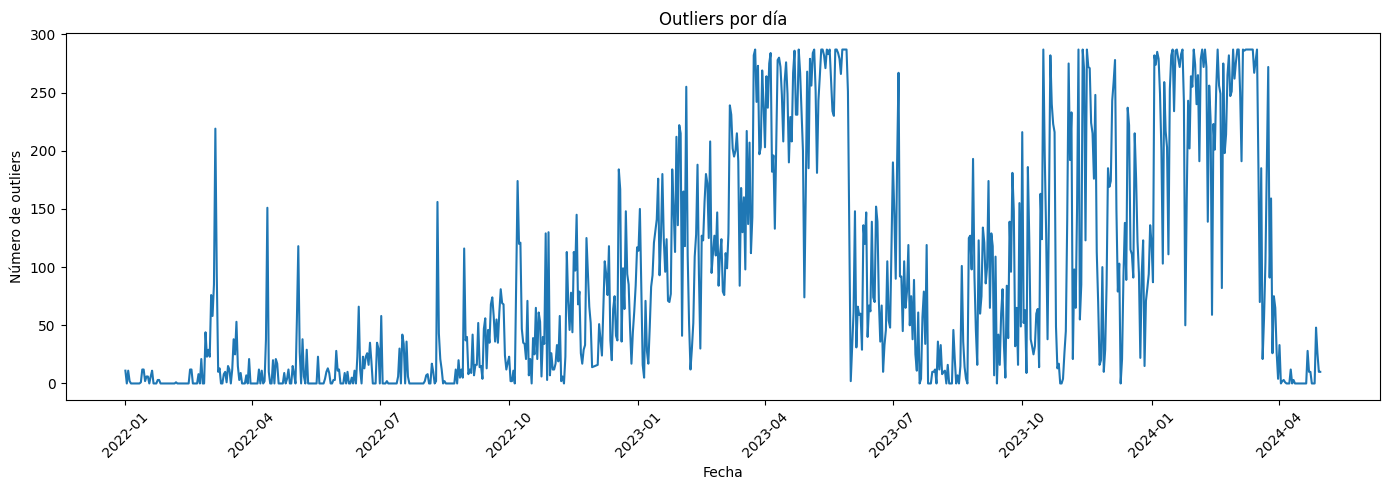

In [17]:
clustering_data_all['date'] = pd.to_datetime(clustering_data_all['timestamp']).dt.date

total_by_day = clustering_data_all.groupby('date').size()
outliers_by_day = (clustering_data_all[clustering_data_all['outliers'] == True]
                   .groupby('date')
                   .size())
# Reindex con todos los días, llenando con 0
outliers_by_day = outliers_by_day.reindex(total_by_day.index, fill_value=0)

outliers_by_day = outliers_by_day.reset_index()
outliers_by_day.columns = ['date', 'outliers']

plt.figure(figsize=(14, 5))
plt.plot(outliers_by_day['date'], outliers_by_day['outliers'])
plt.xlabel('Fecha')
plt.ylabel('Número de outliers')
plt.title('Outliers por día')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

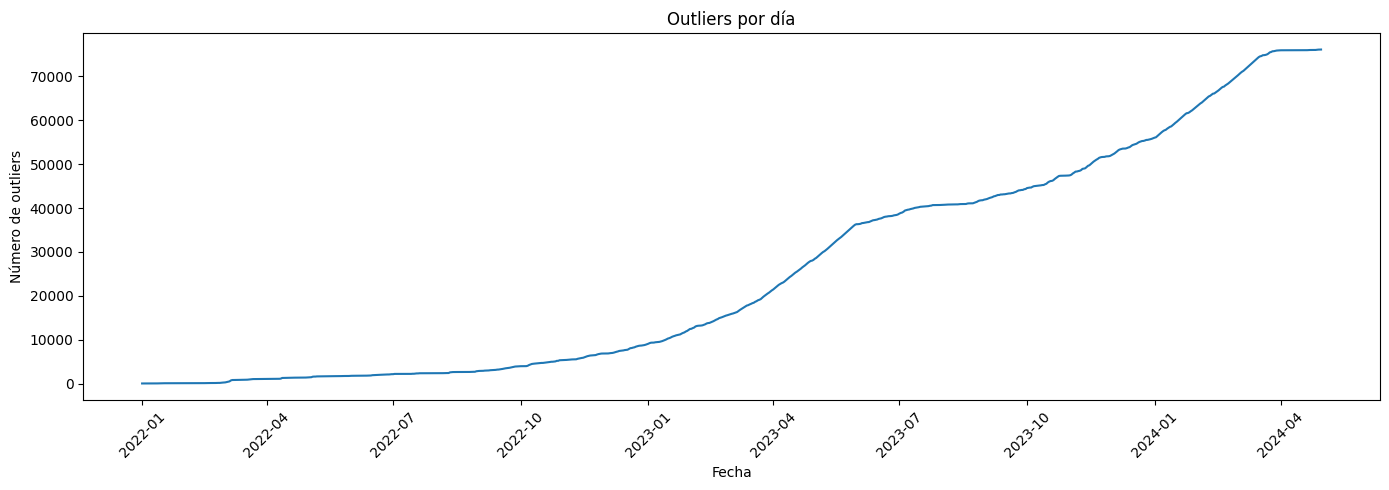

In [21]:
outliers_by_day['cumsum_outiers'] = outliers_by_day['outliers'].cumsum()

plt.figure(figsize=(14, 5))
plt.plot(outliers_by_day['date'], outliers_by_day['cumsum_outiers'])
plt.xlabel('Fecha')
plt.ylabel('Número de outliers')
plt.title('Outliers por día')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [25]:
outliers_by_day.to_csv('first_outliers_file.csv')


In [18]:
date_reprocess = outliers_by_day[outliers_by_day['outliers'] > 150]['date'].iloc[0]

outliers_by_day_1 = outliers_by_day[outliers_by_day['date']<=date_reprocess]

In [19]:
date_reprocess

datetime.date(2022, 3, 6)

In [23]:
from sklearn.metrics import pairwise_distances_argmin_min

# ──────────────────────────────────────────────────────────────
# 1. PREPARAR DATOS NUEVOS (desde el corte original hasta date_reprocess)
# ──────────────────────────────────────────────────────────────
 
# Datos nuevos = lo que NO estaba en el entrenamiento original
features_df_new = features_df[
    (features_df['timestamp'] >= "2022-02-01") &
    (features_df['timestamp'] <= pd.Timestamp(date_reprocess) + pd.Timedelta(days=1))
]
 
clustering_data_new = features_df_new[cols_to_scale].dropna()
 
# IMPORTANTE: usar transform, NO fit_transform — el scaler ya está fitteado
scaled_new = scaler.transform(clustering_data_new[cols_to_scale])
X_new = pd.DataFrame(scaled_new, columns=cols_to_scale, index=clustering_data_new.index)
 
print(f"Datos nuevos a clasificar: {len(X_new)} registros")
 
# ──────────────────────────────────────────────────────────────
# 2. CLASIFICAR CON MODELO BASE CONGELADO
# ──────────────────────────────────────────────────────────────
 
labels_new = km_model_1.predict(X_new.values)
distances_new = km_model_1.transform(X_new.values)
 
clustering_data_new = clustering_data_new.copy()
clustering_data_new['timestamp'] = features_df_new.loc[clustering_data_new.index, 'timestamp']
clustering_data_new['labels'] = labels_new
clustering_data_new['distance_to_centroid'] = [
    distances_new[i, label] for i, label in enumerate(labels_new)
]
clustering_data_new['outliers'] = clustering_data_new['distance_to_centroid'] > upper
 
n_clasificados = (~clustering_data_new['outliers']).sum()
n_outliers = clustering_data_new['outliers'].sum()
print(f"Clasificados en grupos existentes: {n_clasificados}")
print(f"Outliers detectados:               {n_outliers}")
 
# ──────────────────────────────────────────────────────────────
# 3. EXTRAER BUFFER DE OUTLIERS
# ──────────────────────────────────────────────────────────────
 
df_outliers = clustering_data_new[clustering_data_new['outliers']].copy()
X_outliers = scaler.transform(df_outliers[cols_to_scale])  # ya están escalados en X_new,
                                                            # pero por claridad re-escalamos
                                                            # desde las features originales
 
# Alternativa más directa: extraer del array ya escalado
X_outliers = X_new.loc[df_outliers.index].values
 
MIN_PARA_RECLUSTER = 10
MIN_MIEMBROS_GRUPO = 5
MAX_K_BUFFER = 6
 
if len(X_outliers) < MIN_PARA_RECLUSTER:
    print(f"\nSolo {len(X_outliers)} outliers. Insuficientes para re-clustering (mínimo: {MIN_PARA_RECLUSTER}).")
    print("Se quedan como anomalías. Esperando más datos.")
    centroides_expandidos = km_model_1.cluster_centers_.copy()
    nuevos_clusters_encontrados = False
 
else:
    # ──────────────────────────────────────────────────────────
    # 4. RE-CLUSTERING DEL BUFFER (método del codo)
    # ──────────────────────────────────────────────────────────
 
    print(f"\n{'─' * 50}")
    print(f"Re-clustering de {len(X_outliers)} outliers...")
    print(f"{'─' * 50}")
 
    max_k = min(MAX_K_BUFFER, len(X_outliers) - 1)
    inercias = []
    modelos_buffer = []
 
    for k in range(1, max_k + 1):
        km_buf = KMeans(n_clusters=k, random_state=42, n_init=10)
        km_buf.fit(X_outliers)
        inercias.append(km_buf.inertia_)
        modelos_buffer.append(km_buf)
 
    # Método del codo
    mejor_k = 1
    for i in range(1, len(inercias)):
        caida = (inercias[i - 1] - inercias[i]) / (inercias[i - 1] + 1e-10)
        if caida > 0.3:
            mejor_k = i + 1
        else:
            break
 
    km_buffer = modelos_buffer[mejor_k - 1]
    print(f"Mejor k para outliers: {mejor_k}")
 
    # ──────────────────────────────────────────────────────────
    # 5. FILTRAR GRUPOS VÁLIDOS Y PROMOVER
    # ──────────────────────────────────────────────────────────
 
    buffer_labels = km_buffer.labels_
    n_original = len(km_model_1.cluster_centers_)
    nuevos_centroides = []
 
    for k in range(mejor_k):
        n_miembros = (buffer_labels == k).sum()
        centro = km_buffer.cluster_centers_[k]
 
        if n_miembros >= MIN_MIEMBROS_GRUPO:
            nuevo_id = n_original + len(nuevos_centroides)
            nuevos_centroides.append(centro)
            print(f"  ✓ Promovido → Cluster {nuevo_id} ({n_miembros} miembros)")
        else:
            print(f"  ✗ Descartado ({n_miembros} miembros) — ruido disperso")
 
    # ──────────────────────────────────────────────────────────
    # 6. CONSTRUIR CENTROIDES EXPANDIDOS
    # ──────────────────────────────────────────────────────────
 
    if nuevos_centroides:
        centroides_expandidos = np.vstack([
            km_model_1.cluster_centers_,
            np.array(nuevos_centroides)
        ])
        nuevos_clusters_encontrados = True
        print(f"\nModelo expandido: {n_original} originales + "
              f"{len(nuevos_centroides)} nuevos = {len(centroides_expandidos)} clusters")
    else:
        centroides_expandidos = km_model_1.cluster_centers_.copy()
        nuevos_clusters_encontrados = False
        print("\nNo se encontraron grupos válidos entre los outliers.")
 
# ──────────────────────────────────────────────────────────────
# 7. RECLASIFICAR TODO (run + new) CON CENTROIDES EXPANDIDOS
# ──────────────────────────────────────────────────────────────
 
print(f"\n{'─' * 50}")
print("Reclasificando dataset completo con centroides expandidos...")
print(f"{'─' * 50}")
 
# Concatenar datos originales + nuevos (features sin escalar)
clustering_data_all = pd.concat([clustering_data_run, clustering_data_new], axis=0)
clustering_data_all = clustering_data_all.sort_values('timestamp')
 
# Escalar todo con el scaler original
X_all_scaled = scaler.transform(clustering_data_all[cols_to_scale])
 
# Clasificar contra centroides expandidos
closest, dists = pairwise_distances_argmin_min(X_all_scaled, centroides_expandidos)
labels_expanded = np.where(dists <= upper, closest, -1)
 
clustering_data_all['labels_expanded'] = labels_expanded
clustering_data_all['distance_expanded'] = dists
clustering_data_all['outliers_expanded'] = labels_expanded == -1
 
# Reporte final
n_antes = clustering_data_all['outliers'].sum()
n_despues = clustering_data_all['outliers_expanded'].sum()
print(f"\nOutliers antes:              {n_antes}")
print(f"Outliers después:            {n_despues}")
print(f"Reclasificados en nuevos:    {n_antes - n_despues}")
 
print("\nDistribución de labels expandidos:")
print(clustering_data_all['labels_expanded'].value_counts().sort_index())
 

Datos nuevos a clasificar: 9758 registros
Clasificados en grupos existentes: 9147
Outliers detectados:               611

──────────────────────────────────────────────────
Re-clustering de 611 outliers...
──────────────────────────────────────────────────


c:\Users\LENOVO\OneDrive\Documentos\Estancia de Investigación\Estancia_Maestría\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
c:\Users\LENOVO\OneDrive\Documentos\Estancia de Investigación\Estancia_Maestría\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


Mejor k para outliers: 3
  ✓ Promovido → Cluster 3 (49 miembros)
  ✓ Promovido → Cluster 4 (508 miembros)
  ✓ Promovido → Cluster 5 (54 miembros)

Modelo expandido: 3 originales + 3 nuevos = 6 clusters

──────────────────────────────────────────────────
Reclasificando dataset completo con centroides expandidos...
──────────────────────────────────────────────────

Outliers antes:              697
Outliers después:            3
Reclasificados en nuevos:    694

Distribución de labels expandidos:
labels_expanded
-1       3
 0    6852
 1    3704
 2    6199
 3      77
 4    1375
 5     431
Name: count, dtype: int64


In [24]:
clustering_data_all

,energy_movil_mean,kurtosis_mobile_mean,frequency_index_movil_mean,entropy_movil_mean,timestamp,labels,distance_to_centroid,outliers,labels_expanded,distance_expanded,outliers_expanded
10,7.189824,1.016756,0.002807,6566.963119,2022-01-01 00:55:00,2,0.213652,False,2,0.213652,False
11,7.202035,1.135282,0.040282,6541.763823,2022-01-01 01:00:00,2,0.219273,False,2,0.219273,False
12,7.217582,1.225977,0.087732,6484.417105,2022-01-01 01:05:00,2,0.238726,False,2,0.238726,False
13,7.214921,1.221882,0.091360,6501.124913,2022-01-01 01:10:00,2,0.241399,False,2,0.241399,False
14,7.209869,1.217271,0.082832,6542.602102,2022-01-01 01:15:00,2,0.242939,False,2,0.242939,False
...,...,...,...,...,...,...,...,...,...,...,...
18650,9.382968,0.523011,-0.249276,804.498473,2022-03-06 23:35:00,1,0.636336,True,4,0.064408,False
18651,9.405417,0.520679,-0.253252,780.909250,2022-03-06 23:40:00,1,0.642918,True,4,0.070182,False
18652,9.431832,0.522627,-0.262939,759.592267,2022-03-06 23:45:00,1,0.652147,True,4,0.076581,False
18653,9.461849,0.521044,-0.270432,740.673324,2022-03-06 23:50:00,1,0.661008,True,4,0.084443,False


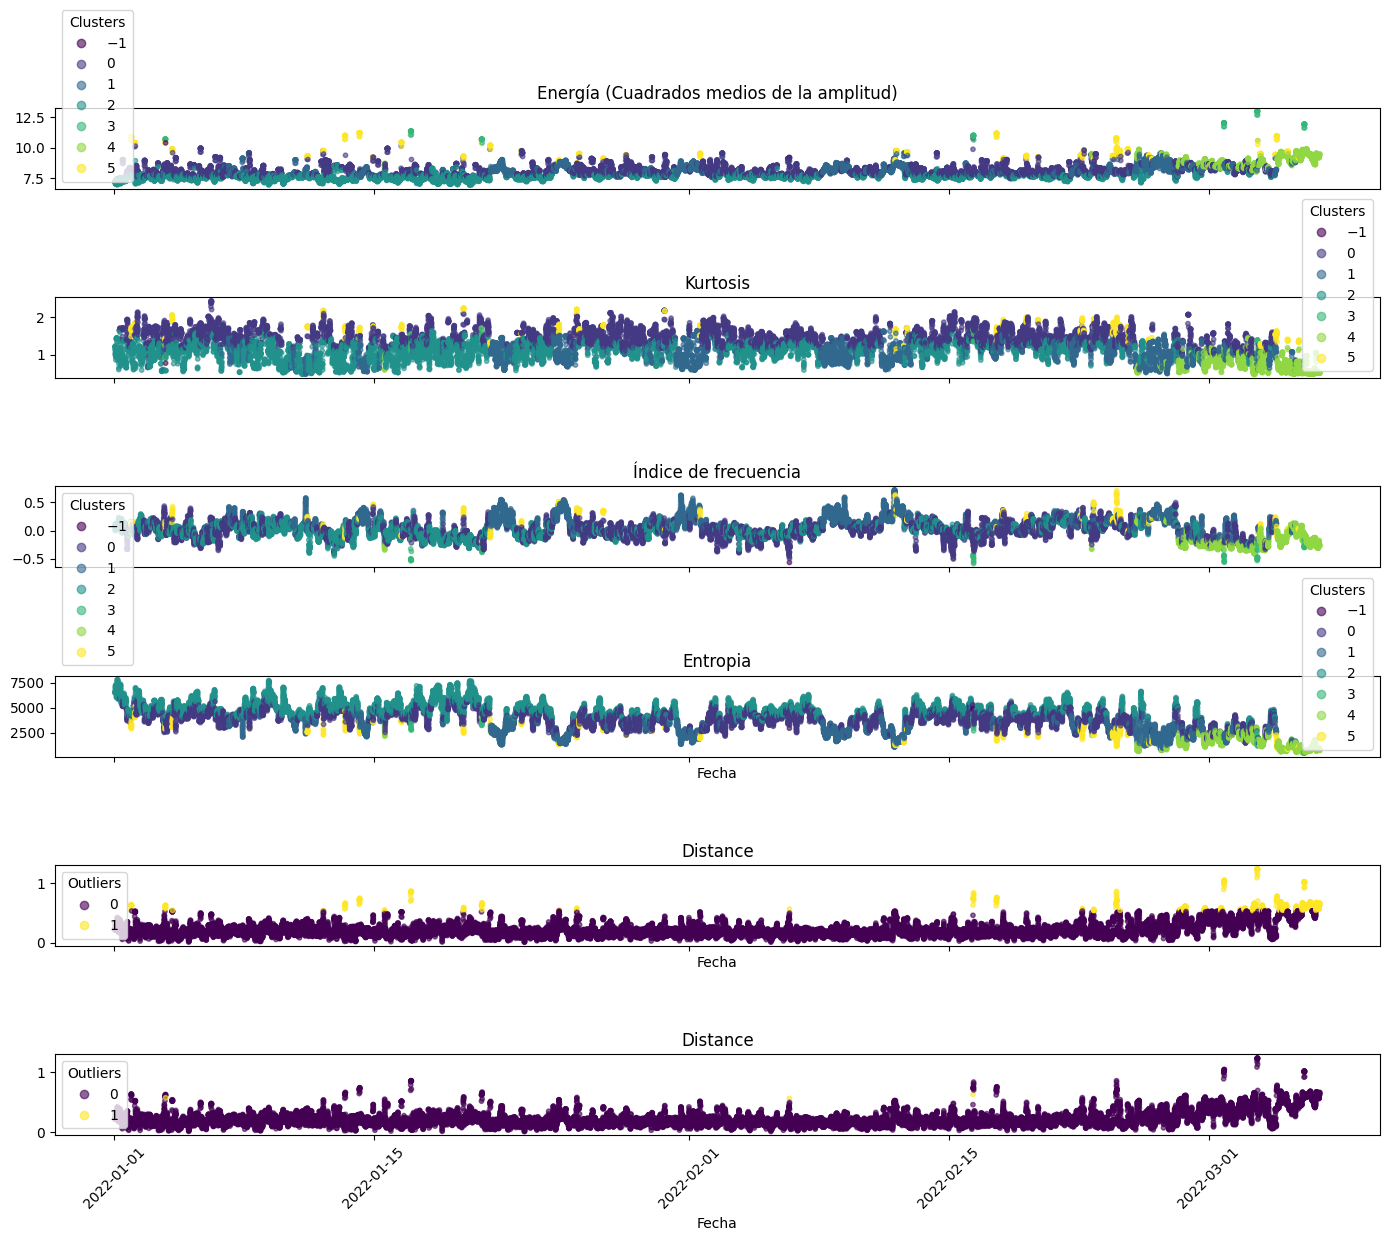

In [31]:
# Generate the plot
fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(14, 12), sharex=True)
scatter = axes[0].scatter(clustering_data_all['timestamp'], clustering_data_all['energy_movil_mean'], c=clustering_data_all['labels_expanded'], cmap='viridis', s=10, alpha=0.6)
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[1].scatter(clustering_data_all['timestamp'], clustering_data_all['kurtosis_mobile_mean'], c=clustering_data_all['labels_expanded'], cmap='viridis', s=10, alpha=0.6)
axes[1].set_title('Kurtosis')
axes[1].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[2].scatter(clustering_data_all['timestamp'], clustering_data_all['frequency_index_movil_mean'], c=clustering_data_all['labels_expanded'], cmap='viridis', s=10, alpha=0.6)
axes[2].set_title('Índice de frecuencia')
axes[2].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[3].scatter(clustering_data_all['timestamp'], clustering_data_all['entropy_movil_mean'], c=clustering_data_all['labels_expanded'], cmap='viridis', s=10, alpha=0.6)
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(*scatter.legend_elements(), title="Clusters")


scatter = axes[4].scatter(clustering_data_all['timestamp'], clustering_data_all['distance_to_centroid'], c=clustering_data_all['outliers'], s=10, alpha=0.6)
axes[4].set_title('Distance')
axes[4].set_xlabel('Fecha')
axes[4].legend(*scatter.legend_elements(), title="Outliers")

scatter = axes[5].scatter(clustering_data_all['timestamp'], clustering_data_all['distance_to_centroid'], c=clustering_data_all['outliers_expanded'], s=10, alpha=0.6)
axes[5].set_title('Distance')
axes[5].set_xlabel('Fecha')
axes[5].legend(*scatter.legend_elements(), title="Outliers")

plt.xticks(rotation=45)
plt.tight_layout()

In [27]:

import joblib  # para persistir modelo y scaler

# ──────────────────────────────────────────────────────────────
# 8. PERSISTIR PARA CLASIFICAR DATOS FUTUROS
# ──────────────────────────────────────────────────────────────
 
# Guardar scaler, centroides expandidos y umbral
joblib.dump(scaler, 'scaler_fitted.joblib')
np.save('centroides_expandidos.npy', centroides_expandidos)
joblib.dump(upper, 'upper_threshold.joblib')
 
print("\nArchivos guardados:")
print("  - scaler_fitted.joblib")
print("  - centroides_expandidos.npy")
print("  - upper_threshold.joblib")
 
# ──────────────────────────────────────────────────────────────
# 9. FUNCIÓN PARA CLASIFICAR DATOS FUTUROS
# ──────────────────────────────────────────────────────────────
 
def clasificar_nueva_data(features_df_futuro, scaler, centroides_expandidos, upper, cols_to_scale):
    """
    Clasifica datos que lleguen en el futuro usando:
      - El scaler original (MinMaxScaler fitteado en el primer tramo)
      - Los centroides expandidos (originales + promovidos)
      - El umbral upper para detectar nuevas anomalías
 
    Parameters
    ----------
    features_df_futuro : pd.DataFrame
        Datos nuevos con las columnas de cols_to_scale ya calculadas
        (moving averages, log transforms, etc.)
    scaler : MinMaxScaler
        Scaler ya fitteado (NO se re-fittea)
    centroides_expandidos : np.ndarray
        Centroides originales + promovidos
    upper : float
        Umbral de distancia para outliers
    cols_to_scale : list
        Nombres de las features
 
    Returns
    -------
    pd.DataFrame con columnas: labels, distance_to_centroid, outliers
    """
    df = features_df_futuro[cols_to_scale].dropna().copy()
 
    # Escalar con el scaler original
    X_scaled = scaler.transform(df[cols_to_scale])
 
    # Clasificar contra centroides expandidos
    closest, dists = pairwise_distances_argmin_min(X_scaled, centroides_expandidos)
    labels = np.where(dists <= upper, closest, -1)
 
    df['labels'] = labels
    df['distance_to_centroid'] = dists
    df['outliers'] = labels == -1
 
    return df
 
 
# ──────────────────────────────────────────────────────────────
# EJEMPLO DE USO FUTURO (en otra sesión / notebook):
# ──────────────────────────────────────────────────────────────
#
#   scaler = joblib.load('scaler_fitted.joblib')
#   centroides_expandidos = np.load('centroides_expandidos.npy')
#   upper = joblib.load('upper_threshold.joblib')
#
#   resultado = clasificar_nueva_data(
#       features_df_futuro=nueva_data,
#       scaler=scaler,
#       centroides_expandidos=centroides_expandidos,
#       upper=upper,
#       cols_to_scale=cols_to_scale
#   )
#
#   # Las que salgan como outliers → van al buffer → eventualmente re-cluster


Archivos guardados:
  - scaler_fitted.joblib
  - centroides_expandidos.npy
  - upper_threshold.joblib


In [ ]:
# ──────────────────────────────────────────────────────────────
# EJEMPLO DE USO FUTURO (en otra sesión / notebook):
# ──────────────────────────────────────────────────────────────#
   

scaler = joblib.load('scaler_fitted.joblib')
centroides_expandidos = np.load('centroides_expandidos.npy')
upper = joblib.load('upper_threshold.joblib')

resultado = clasificar_nueva_data(
       features_df_futuro=nueva_data,
       scaler=scaler,
       centroides_expandidos=centroides_expandidos,
       upper=upper,
       cols_to_scale=cols_to_scale
   )

   # Las que salgan como outliers → van al buffer → eventualmente re-cluster